In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/My Drive/FedFTG-main"

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1HpG6IyuV2ZNt3hDTazjotIp2Cou760rv/FedFTG-main


In [ ]:
from utils import util_dataset, util_parser
import torch
import os
import random
import numpy as np
# from models import model_choose_fn
from models import model_choose_fn
from methods import FedAvg, FedFTG
import matplotlib.pyplot as plt

def run(conf):
    print(f"Running with method: {conf['method']}")
    root_path = os.getcwd()
    if root_path.endswith('scripts'):
        root_path = os.path.dirname(root_path)

    conf['savepath'] = os.path.join(root_path, conf['savepath'].strip())
    print('Data and results save path is: ', conf['savepath'])
    ######################################################
    # Provide reproducibility
    torch.manual_seed(conf['seed'])
    random.seed(conf['seed'])
    np.random.seed(conf['seed'])
    in_channel = 3
    out_channel = 10
    ######################################################
    # Split the dataset
    data_obj = util_dataset.DatasetObject(
        dataset=conf['dataset'],
        n_client=conf['n_client'],
        seed=conf['seed'],
        rule=conf['rule'],
        rule_arg=conf['alpha'],
        unbalanced_sgm=conf['sgm'],
        data_path=conf['savepath'].strip(),
    )

    ######################################################
    # Model selection
    if conf['dataset'] == 'CIFAR100':
        out_channel = 100
    elif conf['dataset'] != 'CIFAR10':
        raise RuntimeError('Unsupported dataset.')

    model_func = lambda: model_choose_fn.choose_model("resnet18", num_classes=out_channel)
    init_model = model_func()

    ######################################################
    # Initialize saving directory
    model_save_path = f"{conf['savepath']}Model/{data_obj.name}/{conf['dataset']}_{conf['model_arch']}_init_mdl.pt"
    if not os.path.exists(model_save_path):
        os.makedirs(os.path.dirname(model_save_path), exist_ok=True)
        torch.save(init_model.state_dict(), model_save_path)
    else:
        init_model.load_state_dict(torch.load(model_save_path))

    ######################################################
    # Train with the specified method
    if conf['method'] == 'FedAvg':
        print('Training with FedAvg...')
        res_all_performance = FedAvg.train_FedAvg(
            data_obj=data_obj,
            act_prob=conf['active_frac'],
            learning_rate=conf['lr'],
            batch_size=conf['bs'],
            epoch=conf['localE'],
            com_amount=conf['comm_amount'],
            print_per=conf['print_freq'],
            weight_decay=conf['weight_decay'],
            model_func=model_func,
            init_model=init_model,
            sch_step=conf['sch_step'],
            sch_gamma=conf['sch_gamma'],
            save_period=conf['save_period'],
            suffix=conf['model_arch'],
            trial=False,
            data_path=conf['savepath'],
            rand_seed=conf['seed'],
            lr_decay_per_round=conf['lr_decay'],
        )[-1]
    elif conf['method'] == 'FedFTG':
        print('Training with FedFTG...')
        g_model_func = lambda: model_choose_fn.choose_g_model(
            model_name = 'CGeneratorA', nz=100, nc=data_obj.channels, img_size=data_obj.width, n_cls=out_channel
        )
        init_g_model = g_model_func()
        res_all_performance = FedFTG.train_FedFTG(
            data_obj=data_obj,
            act_prob=conf['active_frac'],
            learning_rate=conf['lr'],
            batch_size=conf['bs'],
            epoch=conf['localE'],
            com_amount=conf['comm_amount'],
            print_per=conf['print_freq'],
            weight_decay=conf['weight_decay'],
            model_func=model_func,
            init_model=init_model,
            init_g_model=init_g_model,
            sch_step=conf['sch_step'],
            sch_gamma=conf['sch_gamma'],
            save_period=conf['save_period'],
            suffix=conf['model_arch'],
            trial=False,
            data_path=conf['savepath'],
            rand_seed=conf['seed'],
            lr_decay_per_round=conf['lr_decay'],
        )[-1]
    else:
        raise RuntimeError('Unsupported method.')

    ######################################################
    # Plot results
    plotfig(conf['comm_amount'], res_all_performance, f"{conf['method']}_Performance", conf['method'])

def plotfig(com_amount, res, name, method):
    plt.figure(figsize=(6, 5))
    plt.plot(np.arange(com_amount) + 1, res[:com_amount, 1], label=method)
    plt.ylabel('Test Accuracy', fontsize=16)
    plt.xlabel('Communication Rounds', fontsize=16)
    plt.legend(fontsize=16, loc='lower right', bbox_to_anchor=(1.015, -0.02))
    plt.grid()
    plt.xlim([0, com_amount + 2])
    plt.title(name, fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.savefig(f"{name}.pdf", dpi=1000, bbox_inches='tight')

Running with method: FedFTG
Data and results save path is:  /content/drive/.shortcut-targets-by-id/1HpG6IyuV2ZNt3hDTazjotIp2Cou760rv/FedFTG-main/./results/
Data is already downloaded
Class frequencies:
Client   0: 0.549, 0.235, 0.018, 0.123, 0.043, 0.000, 0.003, 0.004, 0.022, 0.003, Amount:5000
Client   1: 0.026, 0.009, 0.098, 0.188, 0.011, 0.249, 0.136, 0.145, 0.110, 0.028, Amount:5000
Client   2: 0.081, 0.001, 0.055, 0.084, 0.000, 0.458, 0.119, 0.043, 0.126, 0.034, Amount:5000
Client   3: 0.032, 0.004, 0.003, 0.086, 0.582, 0.000, 0.070, 0.047, 0.143, 0.033, Amount:5000
Client   4: 0.032, 0.041, 0.011, 0.081, 0.000, 0.000, 0.000, 0.629, 0.124, 0.083, Amount:5000
Client   5: 0.034, 0.030, 0.004, 0.067, 0.345, 0.000, 0.036, 0.024, 0.086, 0.375, Amount:5000
Client   6: 0.010, 0.642, 0.041, 0.077, 0.000, 0.130, 0.040, 0.012, 0.038, 0.010, Amount:5000
Client   7: 0.006, 0.000, 0.763, 0.065, 0.000, 0.000, 0.031, 0.002, 0.126, 0.007, Amount:5000
Client   8: 0.198, 0.038, 0.005, 0.076, 0.019,

<ipython-input-2-0ed13120ba23>:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  init_model.load_state_dict(torch.load(model_save_path))


Training with FedFTG...
Received model_name: CGeneratorA
Selected Clients:  0,  1,  2,  3,  4,  5,  6,  7,  8,  9
---- Training client 0
Epoch   0, Training Accuracy: 0.1296, Loss: 2.9792, LR: 0.0010
Epoch   5, Training Accuracy: 0.6194, Loss: 1501.5582, LR: 0.0010
Epoch  10, Training Accuracy: 0.6886, Loss: 6001.3780, LR: 0.0010
---- Training client 1
Epoch   0, Training Accuracy: 0.0798, Loss: 2.9864, LR: 0.0010
Epoch   5, Training Accuracy: 0.3286, Loss: 1502.2960, LR: 0.0010
Epoch  10, Training Accuracy: 0.3540, Loss: 6002.1663, LR: 0.0010
---- Training client 2
Epoch   0, Training Accuracy: 0.0840, Loss: 2.9714, LR: 0.0010
Epoch   5, Training Accuracy: 0.5322, Loss: 1501.9435, LR: 0.0010
Epoch  10, Training Accuracy: 0.5578, Loss: 6001.7968, LR: 0.0010
---- Training client 3
Epoch   0, Training Accuracy: 0.1046, Loss: 3.0235, LR: 0.0010
Epoch   5, Training Accuracy: 0.6374, Loss: 1501.6570, LR: 0.0010
Epoch  10, Training Accuracy: 0.6522, Loss: 6001.5570, LR: 0.0010
---- Training 

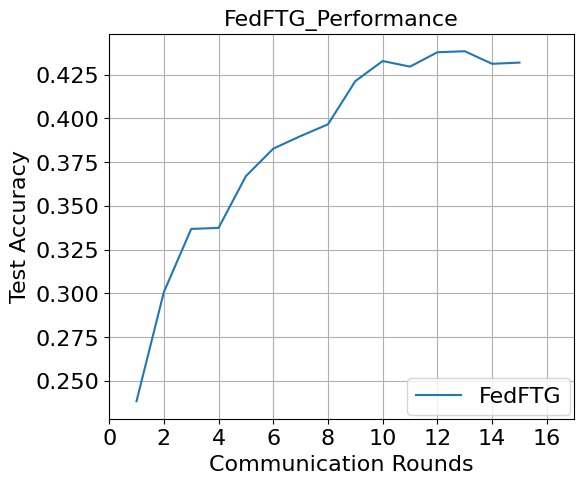

In [ ]:
experiments = [
      {
          'seed': 1024,
          'model_arch': 'resnet18',
          'method': 'FedFTG',
          'dataset': 'CIFAR10',
          'print_freq': 5,
          'save_period': 200,
          'n_client': 10,
          'rule': 'Drichlet',
          'alpha': 0.1,
          'sgm': 0,
          'localE': 10,
          'comm_amount': 15,
          'active_frac': 1,
          'bs': 50,
          'lr': 0.001,
          'weight_decay': 1e-3,
          'lr_decay': 0.998,
          'coef_alpha': 1e-2,
          'savepath': './results/',
          'sch_step': 1,
          'sch_gamma': 1.0,
      },
]

for conf in experiments:
  run(conf)